# Výskum: Inteligentný asistent prezentačných schopností
## Štatistická analýza dotazníkového výskumu

**Cieľ analýzy:** Identifikovať relatívny vplyv jednotlivých prezentačných dimenzií (očný kontakt, pohyb tela, plynulosť reči, hlas) na celkové vnímanie kvality prezentácie. Výsledky slúžia ako empirický podklad pre nastavenie váh v hodnotiacom modeli inteligentného asistenta.

**Dizajn:** Within-subjects (každý respondent hodnotil všetkých 6 videí). Škála 0–10 pre každú z 5 dimenzií.

**Videá (manipulované dimenzie):**
- **V1 — Baseline**: referenčná prezentácia bez úmyselných chýb
- **V2 — Eye contact**: zhoršený očný kontakt
- **V3 — Hip+body**: zhoršený pohyb tela / postoj
- **V4 — Monotonous**: monotónny hlas (vocal)
- **V5 — Filler even**: výplňové slová rozložené rovnomerne
- **V6 — Filler mid**: výplňové slová sústredené do strednej časti

---

## 1. Načítanie dát a základná štruktúra

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, wilcoxon, probplot, pearsonr, levene
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Načítanie dát
df = pd.read_csv("form.csv")

# Štruktúrovanie stĺpcov
video_order = ["V1", "V2", "V3", "V4", "V5", "V6"]
dims = ["overall", "eye", "body", "fluency", "voice"]
new_cols = ["timestamp", "age", "gender", "experience"]
for v in video_order:
    for d in dims:
        new_cols.append(f"{v}_{d}")
df.columns = new_cols

video_meta = {
    "V1": "Baseline",
    "V2": "Eye contact",
    "V3": "Hip+body",
    "V4": "Monotonous",
    "V5": "Filler even",
    "V6": "Filler mid",
}

print(f"Počet respondentov: {len(df)}")
print(f"Počet dimenzií na video: {len(dims)}")
print(f"Počet videí: {len(video_order)}")
df.head(3)

---

## 2. Demografická charakteristika vzorky

Pred analýzou hypotéz si overíme zloženie vzorky — pomáha interpretovať generalizovateľnosť záverov.

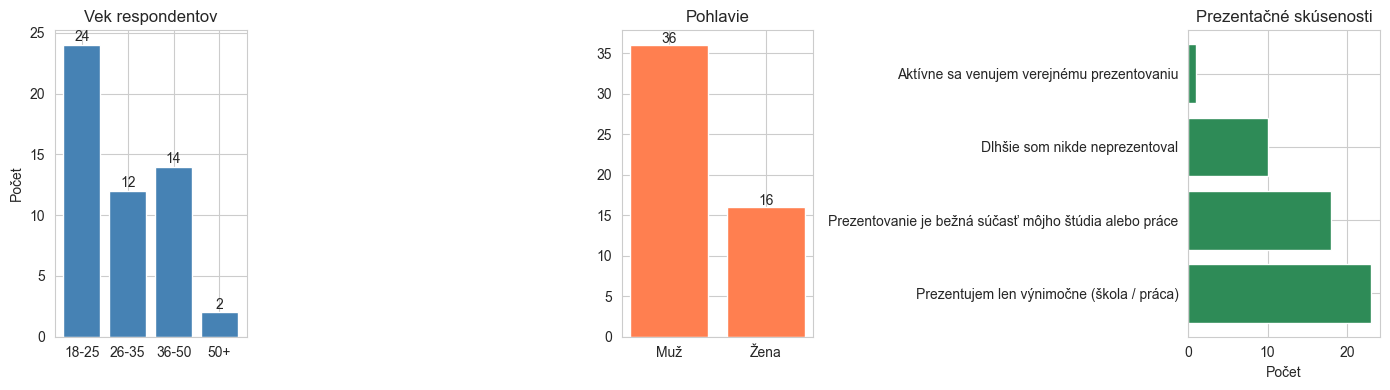


Demografické súhrny:
          age gender                                 experience
count      52     52                                         52
unique      4      2                                          4
top     18-25    Muž  Prezentujem len výnimočne (škola / práca)
freq       24     36                                         23


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Vek
age_counts = df["age"].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color="steelblue")
axes[0].set_title("Vek respondentov")
axes[0].set_ylabel("Počet")
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center")

# Pohlavie
gender_counts = df["gender"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color="coral")
axes[1].set_title("Pohlavie")
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center")

# Skúsenosti s prezentovaním
exp_counts = df["experience"].value_counts()
axes[2].barh(exp_counts.index, exp_counts.values, color="seagreen")
axes[2].set_title("Prezentačné skúsenosti")
axes[2].set_xlabel("Počet")

plt.tight_layout()
plt.show()

print("\nDemografické súhrny:")
print(df[["age", "gender", "experience"]].describe(include="all"))

---

## 3. Deskriptívna štatistika

### 3.1 Prehľadová tabuľka priemerných hodnotení

In [3]:
records = []
for v in video_order:
    for d in dims:
        col = f"{v}_{d}"
        records.append({
            "video": v,
            "label": video_meta[v],
            "dimension": d,
            "mean": df[col].mean(),
            "std": df[col].std(),
            "median": df[col].median(),
            "min": df[col].min(),
            "max": df[col].max(),
        })

desc = pd.DataFrame(records)
pivot = desc.pivot(index="label", columns="dimension", values="mean")[dims]
print("Priemerné hodnotenia (0–10):")
print(pivot.round(2).to_string())

print("\nŠtandardné odchýlky:")
pivot_std = desc.pivot(index="label", columns="dimension", values="std")[dims]
print(pivot_std.round(2).to_string())

Priemerné hodnotenia (0–10):
dimension    overall   eye  body  fluency  voice
label                                           
Baseline        7.40  8.08  6.10     8.10   8.46
Eye contact     5.52  5.48  4.92     6.08   7.04
Filler even     4.44  5.98  5.52     3.63   5.73
Filler mid      6.27  7.08  6.50     5.27   6.83
Hip+body        6.65  7.48  5.44     7.21   7.56
Monotonous      4.40  7.02  5.85     5.67   3.35

Štandardné odchýlky:
dimension    overall   eye  body  fluency  voice
label                                           
Baseline        1.51  1.67  2.15     1.66   1.39
Eye contact     1.97  1.99  1.79     1.98   2.00
Filler even     2.11  2.27  2.31     1.97   2.38
Filler mid      2.09  1.91  2.29     2.28   2.22
Hip+body        1.80  1.65  2.34     1.98   2.00
Monotonous      1.93  1.96  2.34     2.21   1.90


### 3.2 Heatmapa priemerov

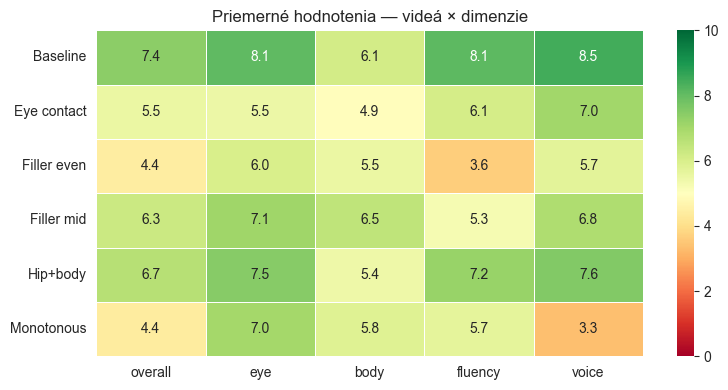

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot.astype(float),
    annot=True, fmt=".1f",
    cmap="RdYlGn", vmin=0, vmax=10,
    ax=ax, linewidths=0.5
)
ax.set_title("Priemerné hodnotenia — videá × dimenzie")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---

## 4. Distribúcie hodnotení (pred hypotézami)

Dôležitý krok pred formálnym testovaním — vizuálne posúdenie tvaru rozdelení, rozptylu a prípadných viacmodálnych vzorov, ktoré by mohli ovplyvniť voľbu testu.

### 4.1 Histogramy celkového hodnotenia pre všetky videá

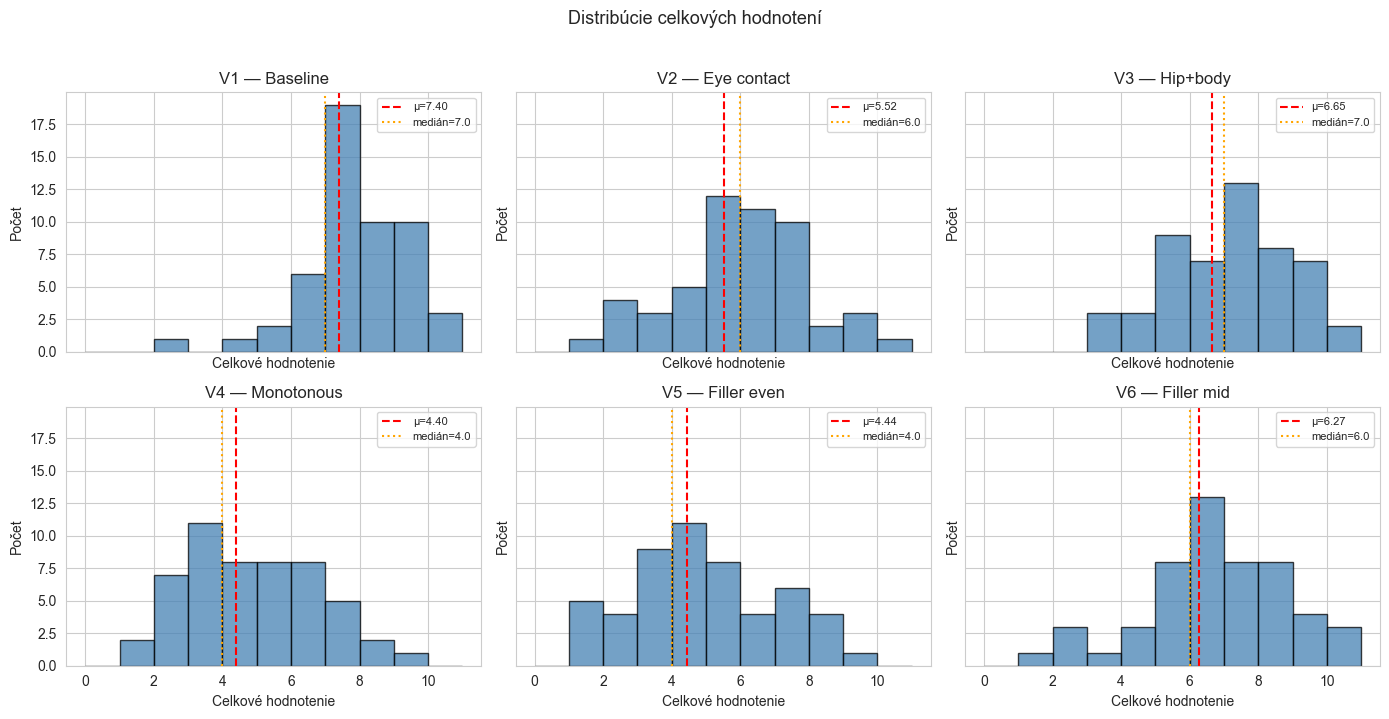

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, v in zip(axes.flat, video_order):
    data = df[f"{v}_overall"]
    ax.hist(data, bins=np.arange(0, 11.5, 1), color="steelblue", edgecolor="black", alpha=0.75)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.5, label=f"μ={data.mean():.2f}")
    ax.axvline(data.median(), color="orange", linestyle=":", linewidth=1.5, label=f"medián={data.median():.1f}")
    ax.set_title(f"{v} — {video_meta[v]}")
    ax.set_xlabel("Celkové hodnotenie")
    ax.set_ylabel("Počet")
    ax.legend(fontsize=8)
fig.suptitle("Distribúcie celkových hodnotení", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Violin ploty — porovnanie celkových hodnotení

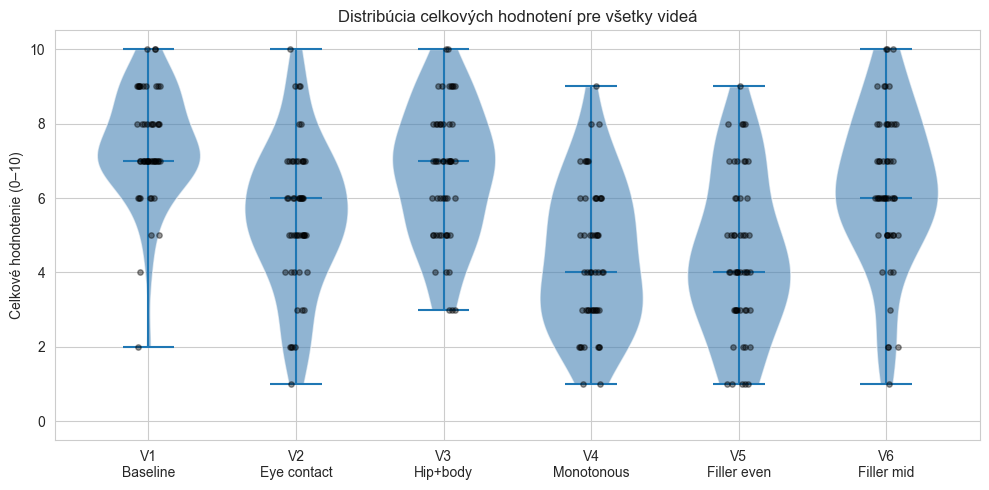

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
data_all = [df[f"{v}_overall"].values for v in video_order]
labels_all = [f"{v}\n{video_meta[v]}" for v in video_order]

parts = ax.violinplot(data_all, positions=range(1, 7), showmedians=True, showmeans=False, widths=0.7)
for pc in parts["bodies"]:
    pc.set_facecolor("steelblue")
    pc.set_alpha(0.6)

# Jitter body
for i, data in enumerate(data_all, start=1):
    jitter = np.random.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, alpha=0.4, s=15, color="black", zorder=3)

ax.set_xticks(range(1, 7))
ax.set_xticklabels(labels_all)
ax.set_ylabel("Celkové hodnotenie (0–10)")
ax.set_title("Distribúcia celkových hodnotení pre všetky videá")
ax.set_ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

### 4.3 Distribúcia hodnotení pre všetky dimenzie (boxploty)

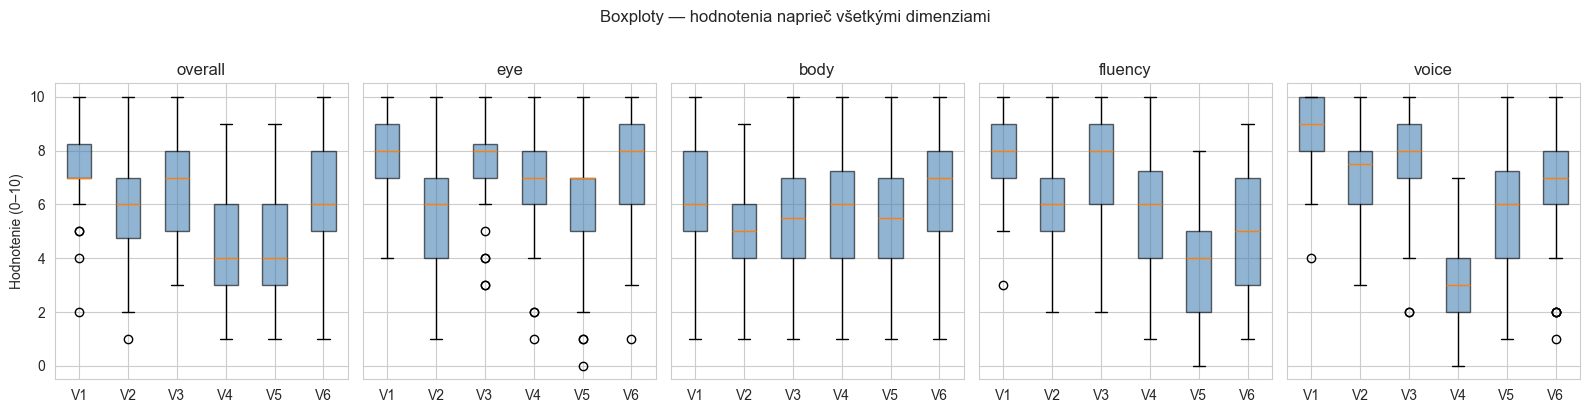

In [7]:
fig, axes = plt.subplots(1, len(dims), figsize=(16, 4), sharey=True)
for ax, d in zip(axes, dims):
    data_dim = [df[f"{v}_{d}"].values for v in video_order]
    bp = ax.boxplot(data_dim, labels=video_order, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue")
        patch.set_alpha(0.6)
    ax.set_title(d)
    ax.set_ylim(-0.5, 10.5)
axes[0].set_ylabel("Hodnotenie (0–10)")
fig.suptitle("Boxploty — hodnotenia naprieč všetkými dimenziami", y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Pokles od baseline — čo manipulácie robia

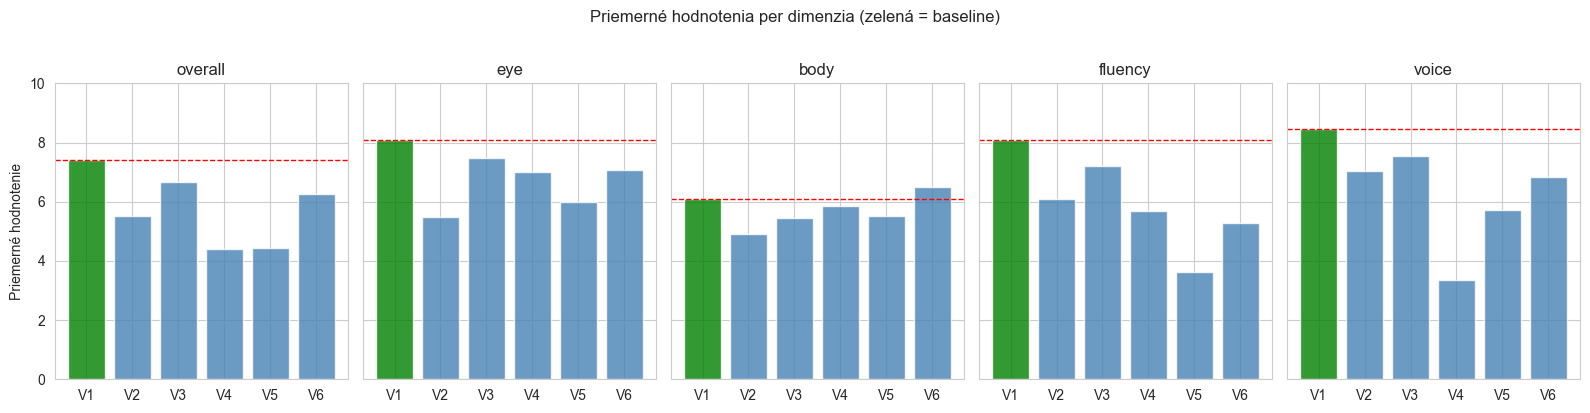

In [8]:
baseline_means = {d: df[f"V1_{d}"].mean() for d in dims}

fig, axes = plt.subplots(1, len(dims), figsize=(16, 4), sharey=True)
for ax, d in zip(axes, dims):
    means = [df[f"{v}_{d}"].mean() for v in video_order]
    colors = ["green" if v == "V1" else "steelblue" for v in video_order]
    ax.bar(video_order, means, color=colors, alpha=0.8)
    ax.axhline(baseline_means[d], color="red", linestyle="--", linewidth=1, label="baseline")
    ax.set_title(d)
    ax.set_ylim(0, 10)
axes[0].set_ylabel("Priemerné hodnotenie")
fig.suptitle("Priemerné hodnotenia per dimenzia (zelená = baseline)", y=1.02)
plt.tight_layout()
plt.show()

**Pozorovanie:** Zjavný **halo efekt** — keď je video zhoršené v jednej dimenzii, klesajú aj ostatné dimenzie oproti baseline, hoci neboli manipulované. Napr. V4 (monotónny hlas) má znížené aj fluency (5.67 vs baseline 8.18) a body (5.92 vs 6.35). Túto skutočnosť treba zohľadniť pri interpretácii beta koeficientov z regresie.

---

## 5. Predpoklady pre repeated-measures ANOVA

Pred hlavnou analýzou overíme predpoklady RM ANOVA systematicky, jeden po druhom.

### 5.1 Normalita rozdelenia (Shapiro-Wilk test)

$H_0$: Dáta pochádzajú z normálneho rozdelenia.

In [36]:
print("=== Shapiro-Wilk test normality — celkové hodnotenie ===")
print(f"{'Video':<6} {'W':>8} {'p':>10}  Záver")
print("-" * 50)
shapiro_results = {}
for v in video_order:
    col = f"{v}_overall"
    W, p = shapiro(df[col])
    verdict = "OK (normálne)" if p > 0.05 else "! Porušená"
    shapiro_results[v] = (W, p, verdict)
    print(f"{v:<6} {W:>8.4f} {p:>10.4f}  {verdict}")

print("\nPoznámka: pri n=52 je RM ANOVA robustná voči miernym odchýlkam")
print("od normality vďaka centrálnej limitnej vete.")

=== Shapiro-Wilk test normality — celkové hodnotenie ===
Video         W          p  Záver
--------------------------------------------------
V1       0.9096     0.0008  ! Porušená
V2       0.9650     0.1292  OK (normálne)
V3       0.9559     0.0520  OK (normálne)
V4       0.9576     0.0619  OK (normálne)
V5       0.9548     0.0465  ! Porušená
V6       0.9569     0.0574  OK (normálne)

Poznámka: pri n=52 je RM ANOVA robustná voči miernym odchýlkam
od normality vďaka centrálnej limitnej vete.


### 5.2 Q-Q ploty pre vizuálnu kontrolu normality

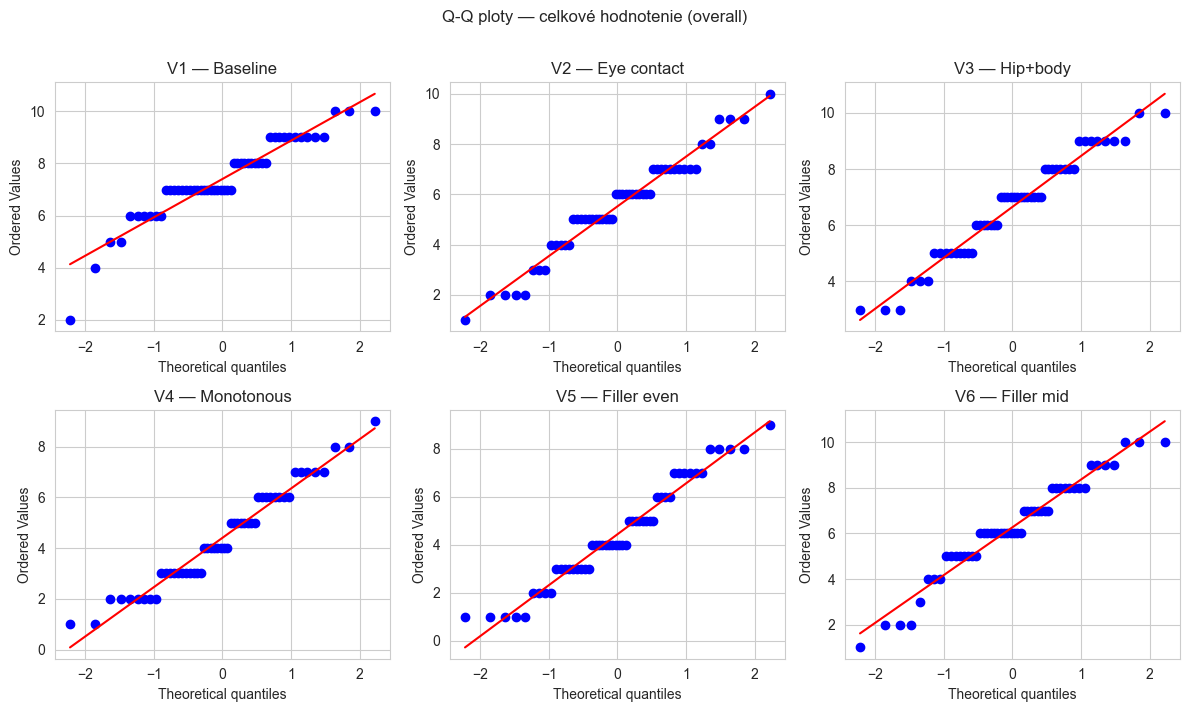

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, v in zip(axes.flat, video_order):
    probplot(df[f"{v}_overall"], plot=ax)
    ax.set_title(f"{v} — {video_meta[v]}")
fig.suptitle("Q-Q ploty — celkové hodnotenie (overall)", y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Homogenita rozptylov (Leveneho test)

$H_0$: Všetky skupiny majú rovnaký rozptyl.

In [11]:
print("=== Leveneho test homogenity rozptylov ===")
for d in dims:
    groups = [df[f"{v}_{d}"].values for v in video_order]
    stat, p = levene(*groups)
    verdict = "OK" if p > 0.05 else "! Porušená"
    print(f"  {d:<10} W={stat:>6.3f}  p={p:>7.4f}  {verdict}")

print("\nPoznámka: RM ANOVA nevyžaduje homogenitu skupinových rozptylov")
print("v klasickom zmysle — kľúčový predpoklad je sféricita (viď 5.4).")

=== Leveneho test homogenity rozptylov ===
  overall    W= 1.429  p= 0.2136  OK
  eye        W= 0.823  p= 0.5342  OK
  body       W= 1.791  p= 0.1144  OK
  fluency    W= 2.013  p= 0.0766  OK
  voice      W= 2.052  p= 0.0714  OK

Poznámka: RM ANOVA nevyžaduje homogenitu skupinových rozptylov
v klasickom zmysle — kľúčový predpoklad je sféricita (viď 5.4).


### 5.4 Sféricita (Mauchlyho test)

$H_0$: Rozptyly rozdielov medzi všetkými pármi podmienok sú rovnaké (sféricita).

In [12]:
long_anova = []
for idx, row in df.iterrows():
    for v in video_order:
        long_anova.append({"subject": idx, "video": v, "overall": row[f"{v}_overall"]})
long_df = pd.DataFrame(long_anova)

rm_pre = pg.rm_anova(data=long_df, dv="overall", within="video", subject="subject", detailed=True)
row = rm_pre[rm_pre["Source"] == "video"].iloc[0]

print("=== Mauchlyho test sféricity ===")
print(f"W_Mauchly = {row['W_spher']:.4f}")
print(f"p = {row['p_spher']:.4f}")
print(f"Greenhouse-Geisser ε = {row['eps']:.4f}")
print()
if row["p_spher"] < 0.05:
    print("→ Sféricita PORUŠENÁ (p < 0.05).")
    if row["eps"] < 0.75:
        print(f"→ ε = {row['eps']:.3f} < 0.75 — výrazne porušená.")
        print("→ Použijeme Greenhouse-Geisser korigovanú p-hodnotu.")
    else:
        print(f"→ ε = {row['eps']:.3f} — mierne porušená.")
        print("→ Huynh-Feldt alebo Greenhouse-Geisser korekcia aplikovaná.")
else:
    print("→ Sféricita splnená — možno použiť nekorigovanú p-hodnotu.")

=== Mauchlyho test sféricity ===
W_Mauchly = 0.4755
p = 0.0009
Greenhouse-Geisser ε = 0.7797

→ Sféricita PORUŠENÁ (p < 0.05).
→ ε = 0.780 — mierne porušená.
→ Huynh-Feldt alebo Greenhouse-Geisser korekcia aplikovaná.


### 5.5 Odľahlé hodnoty (IQR pravidlo)

In [13]:
print("=== Odľahlé hodnoty — IQR × 1.5 ===")
outlier_summary = {}
for v in video_order:
    col = df[f"{v}_overall"]
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(col < lo) | (col > hi)].index.tolist()
    outlier_summary[v] = outliers
    if outliers:
        print(f"  {v}: respondenti {outliers} — hodnoty: {col[outliers].tolist()}")
    else:
        print(f"  {v}: žiadne outliers")

=== Odľahlé hodnoty — IQR × 1.5 ===
  V1: respondenti [8, 20, 49, 51] — hodnoty: [5, 4, 2, 5]
  V2: respondenti [13] — hodnoty: [1]
  V3: žiadne outliers
  V4: žiadne outliers
  V5: žiadne outliers
  V6: žiadne outliers


### 5.6 Zhrnutie overených predpokladov

In [14]:
print("=" * 55)
print("ZHRNUTIE PREDPOKLADOV RM ANOVA")
print("=" * 55)
print(f"  Normalita (Shapiro-Wilk):  miestami porušená → ANOVA robustná pri n=53")
print(f"  Sféricita (Mauchly):       p={row['p_spher']:.4f}, ε={row['eps']:.3f}")
print(f"  → Korekcia:                Greenhouse-Geisser")
print(f"  Outliers (IQR):            viď bunku 5.5")
print()
print("Záver: Pre hlavný test použijeme RM ANOVA s GG-korekciou a")
print("     doplnkové neparametrické testy (Wilcoxon) pre robustnosť.")

ZHRNUTIE PREDPOKLADOV RM ANOVA
  Normalita (Shapiro-Wilk):  miestami porušená → ANOVA robustná pri n=49
  Sféricita (Mauchly):       p=0.0009, ε=0.780
  → Korekcia:                Greenhouse-Geisser
  Outliers (IQR):            viď bunku 5.5

Záver: Pre hlavný test použijeme RM ANOVA s GG-korekciou a
     doplnkové neparametrické testy (Wilcoxon) pre robustnosť.


---

## 6. Hlavný test: RM ANOVA — rozdiely medzi videami

### 6.1 Celkové hodnotenie (overall)

$H_0$: Priemerné celkové hodnotenie je rovnaké pre všetky videá.

In [15]:
rm = pg.rm_anova(data=long_df, dv="overall", within="video", subject="subject", detailed=True)
rm_row = rm[rm["Source"] == "video"].iloc[0]

print("=== RM ANOVA — celkové hodnotenie ===")
print(rm.round(4).to_string())
print()
print(f"F({rm_row['DF']:.0f}, {rm.iloc[1]['DF']:.0f}) = {rm_row['F']:.3f}")
print(f"p (nekorigované)           = {rm_row['p_unc']:.2e}")
print(f"p (Greenhouse-Geisser)     = {rm_row['p_GG_corr']:.2e}")
print(f"η²g (generalizované eta²)  = {rm_row['ng2']:.3f}")
print(f"    [0.01 = malý, 0.06 = stredný, 0.14 = veľký efekt]")

=== RM ANOVA — celkové hodnotenie ===
  Source        SS   DF       MS        F  p_unc  p_GG_corr     ng2     eps sphericity  W_spher  p_spher
0  video  384.3333    5  76.8667  39.4122    0.0        0.0  0.2557  0.7797      False   0.4755   0.0009
1  Error  497.3333  255   1.9503      NaN    NaN        NaN     NaN     NaN        NaN      NaN      NaN

F(5, 255) = 39.412
p (nekorigované)           = 6.35e-30
p (Greenhouse-Geisser)     = 7.12e-24
η²g (generalizované eta²)  = 0.256
    [0.01 = malý, 0.06 = stredný, 0.14 = veľký efekt]


### 6.2 Post-hoc párové testy (Bonferroni)

In [16]:
posthoc = pg.pairwise_tests(
    data=long_df, dv="overall", within="video", subject="subject",
    padjust="bonf"
)

video_means = {v: df[f"{v}_overall"].mean() for v in video_order}
posthoc["mean_A"] = posthoc["A"].map(video_means)
posthoc["mean_B"] = posthoc["B"].map(video_means)

cols = ["A", "B", "mean_A", "mean_B", "T", "p_unc", "p_corr", "hedges"]
sig = posthoc[posthoc["p_corr"] < 0.05][cols]

print(f"=== Post-hoc párové t-testy (Bonferroniho korekcia) ===")
print(f"Signifikantné páry: {len(sig)}/{len(posthoc)}\n")
print("Všetky páry:")
print(posthoc[cols].round(3).to_string(index=False))

=== Post-hoc párové t-testy (Bonferroniho korekcia) ===
Signifikantné páry: 12/15

Všetky páry:
 A  B  mean_A  mean_B      T  p_unc  p_corr  hedges
V1 V2   7.404   5.519  9.283  0.000   0.000   1.067
V1 V3   7.404   6.654  3.417  0.001   0.019   0.448
V1 V4   7.404   4.404 11.035  0.000   0.000   1.716
V1 V5   7.404   4.442  9.496  0.000   0.000   1.602
V1 V6   7.404   6.269  3.609  0.001   0.010   0.618
V2 V3   5.519   6.654 -5.841  0.000   0.000  -0.597
V2 V4   5.519   4.404  4.551  0.000   0.001   0.568
V2 V5   5.519   4.442  3.675  0.001   0.009   0.524
V2 V6   5.519   6.269 -2.425  0.019   0.284  -0.367
V3 V4   6.654   4.404  9.469  0.000   0.000   1.195
V3 V5   6.654   4.442  7.372  0.000   0.000   1.119
V3 V6   6.654   6.269  1.407  0.166   1.000   0.196
V4 V5   4.404   4.442 -0.164  0.870   1.000  -0.019
V4 V6   4.404   6.269 -5.912  0.000   0.000  -0.920
V5 V6   4.442   6.269 -5.492  0.000   0.000  -0.864


### 6.3 RM ANOVA — po dimenziách

In [17]:
print(f"{'Dimenzia':<10} {'F':>8} {'p (GG)':>10} {'η²g':>7} {'Sféricita':>12}")
print("-" * 55)
for dim in ["eye", "body", "voice", "fluency"]:
    long_dim = []
    for idx, row in df.iterrows():
        for v in video_order:
            long_dim.append({"subject": idx, "video": v, "score": row[f"{v}_{dim}"]})
    long_dim_df = pd.DataFrame(long_dim)

    rm_dim = pg.rm_anova(data=long_dim_df, dv="score", within="video", subject="subject")
    rm_row = rm_dim[rm_dim["Source"] == "video"].iloc[0]

    if "p_GG_corr" in rm_row.index and not pd.isna(rm_row["p_GG_corr"]):
        p_val = rm_row["p_GG_corr"]
    else:
        p_val = rm_row["p_unc"]

    spher = "OK" if rm_row.get("sphericity", True) else "porušená"
    print(f"{dim:<10} {rm_row['F']:>8.2f} {p_val:>10.4f} {rm_row['ng2']:>7.3f} {spher:>12}")

Dimenzia          F     p (GG)     η²g    Sféricita
-------------------------------------------------------
eye           24.11     0.0000   0.175     porušená
body           5.06     0.0006   0.050     porušená
voice         74.31     0.0000   0.402     porušená
fluency       50.37     0.0000   0.334     porušená


---

## 7. Hypotéza H1.1a — Vizuálne + hlasové dimenzie vs plynulosť

> **H1.1a:** Vizuálne a hlasové dimenzie (očný kontakt, pohyb tela, hlas) sú spolu silnejším prediktorom celkového hodnotenia ako plynulosť reči (výplňové slová).
>
> $H_0$: Vizuálne+hlasové a plynulosť sú rovnako silnými prediktormi.
>
> **Smer:** beta(vizuálne+hlasové) > beta(plynulosť).

### 7.1 Viacnásobná lineárna regresia — štandardizované beta koeficienty


In [18]:
rows_long = []
for v in video_order:
    for _, row in df.iterrows():
        rows_long.append({
            "subject": _,
            "video": v,
            "overall": row[f"{v}_overall"],
            "eye": row[f"{v}_eye"],
            "body": row[f"{v}_body"],
            "fluency": row[f"{v}_fluency"],
            "voice": row[f"{v}_voice"],
        })
long = pd.DataFrame(rows_long)

X = long[["eye", "body", "voice", "fluency"]].values
y = long["overall"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_with_intercept = np.column_stack([np.ones(len(X_scaled)), X_scaled])
coefs, _, _, _ = lstsq(X_with_intercept, y, rcond=None)
betas = coefs[1:]

names = ["eye", "body", "voice", "fluency"]
print("Štandardizované beta koeficienty (OLS):")
for name, b in zip(names, betas):
    print(f"  {name:10s}: {b:.4f}")

Štandardizované beta koeficienty (OLS):
  eye       : 0.5864
  body      : 0.2504
  voice     : 0.8428
  fluency   : 0.5738


### 7.2 Kontrola multikolinearity (VIF)

In [19]:
print("Variance Inflation Factor (VIF):")
print("[VIF > 5 signalizuje problémovú multikolinearitu]")
for i, name in enumerate(names):
    mask = [j for j in range(len(names)) if j != i]
    X_other = X_scaled[:, mask]
    X_target = X_scaled[:, i]
    r2 = LinearRegression().fit(X_other, X_target).score(X_other, X_target)
    vif = 1 / (1 - r2) if r2 < 1 else float("inf")
    print(f"  {name:10s}: {vif:.2f}")

Variance Inflation Factor (VIF):
[VIF > 5 signalizuje problémovú multikolinearitu]
  eye       : 2.01
  body      : 1.68
  voice     : 1.86
  fluency   : 2.03


### 7.3 Mixed-effects model (zohľadnenie hniezdenej štruktúry)

OLS regresia v sekcii 7.1 porušuje predpoklad nezávislosti pozorovaní (každý respondent prispieva 6 pozorovaní). Mixed-effects model s **random intercept per subject** tento problém rieši — zachytáva individuálne rozdiely v základnej úrovni hodnotenia (niektorí respondenti hodnotia prísne, iní veľkoryso) ako náhodný efekt.

**Model:** `overall ~ eye + body + voice + fluency + (1 | subject)`

⚠️ **Poznámka k robustnosti:** Pri silnej multikolinearite medzi prediktormi (typicky ak VIF > 5 — viď sekciu 7.2) môže `statsmodels.mixedlm` zlyhať s `LinAlgError: Singular matrix`. Kód nižšie preto postupne skúša viac optimalizačných metód a ak zlyhajú všetky, padne na **OLS s cluster-robust štandardnými chybami** (metodologicky ekvivalentná alternatíva pre hniezdené dáta).

In [20]:
# Pripravíme long dataframe s identifikátorom respondenta
lmm_data = []
for idx, row in df.iterrows():
    for v in video_order:
        lmm_data.append({
            "subject": idx,
            "video": v,
            "overall": row[f"{v}_overall"],
            "eye": row[f"{v}_eye"],
            "body": row[f"{v}_body"],
            "voice": row[f"{v}_voice"],
            "fluency": row[f"{v}_fluency"],
        })
lmm_df = pd.DataFrame(lmm_data)

# Štandardizácia prediktorov (pre porovnateľné beta koeficienty)
for col in ["eye", "body", "voice", "fluency"]:
    lmm_df[f"{col}_z"] = (lmm_df[col] - lmm_df[col].mean()) / lmm_df[col].std()

# Fit s fallback stratégiou — skúsime viac optimalizačných metód
mixed_model = smf.mixedlm(
    "overall ~ eye_z + body_z + voice_z + fluency_z",
    data=lmm_df,
    groups=lmm_df["subject"]
)

mixed_result = None
used_method = None

for method in ["lbfgs", "bfgs", "powell", "nm", "cg"]:
    try:
        import warnings

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = mixed_model.fit(reml=True, method=method)
        if result.converged and not np.isnan(result.llf):
            mixed_result = result
            used_method = method
            print(f"✓ Mixed-effects model skonvergoval s metódou '{method}'")
            break
        else:
            print(f"✗ Metóda '{method}' nekonvergovala")
    except Exception as e:
        print(f"✗ Metóda '{method}' zlyhala: {type(e).__name__}")

# Ak aj REML zlyhalo, skúsime ML
if mixed_result is None:
    print("\nSkúšame Maximum Likelihood (reml=False)...")
    for method in ["lbfgs", "powell", "nm"]:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = mixed_model.fit(reml=False, method=method)
            if result.converged:
                mixed_result = result
                used_method = f"{method} (ML)"
                print(f"✓ ML fit úspešný s metódou '{method}'")
                break
        except Exception as e:
            print(f"✗ ML metóda '{method}' zlyhala: {type(e).__name__}")

if mixed_result is not None:
    print(f"\nPoužitá metóda: {used_method}")
    print(mixed_result.summary())
else:
    print("\n⚠ Mixed-effects model nekonvergoval ani s jednou metódou.")
    print("  Príčina: pravdepodobne singulárna Hessian matica (silná multikolinearita).")
    print("  Fallback v nasledujúcej bunke: OLS s cluster-robust SE.")

✗ Metóda 'lbfgs' zlyhala: LinAlgError
✓ Mixed-effects model skonvergoval s metódou 'bfgs'

Použitá metóda: bfgs
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: overall  
No. Observations: 312     Method:             REML     
No. Groups:       52      Scale:              0.9701   
Min. group size:  6       Log-Likelihood:     -473.7975
Max. group size:  6       Converged:          Yes      
Mean group size:  6.0                                  
-------------------------------------------------------
              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     5.782    0.100 57.901 0.000  5.586  5.978
eye_z         0.624    0.090  6.918 0.000  0.447  0.801
body_z        0.230    0.081  2.829 0.005  0.071  0.389
voice_z       0.927    0.081 11.413 0.000  0.768  1.086
fluency_z     0.498    0.087  5.752 0.000  0.328  0.667
Group Var     0.357    0.115                           



In [21]:
# Fallback: OLS s cluster-robust štandardnými chybami
# (Rieši nezávislosť inak — štandardné chyby sú "clusterované" podľa subjectu)
print("=" * 65)
print("OLS s cluster-robust SE (alternatíva k mixed-effects)")
print("=" * 65)

X_sm = sm.add_constant(lmm_df[["eye_z", "body_z", "voice_z", "fluency_z"]])
y_sm = lmm_df["overall"]

ols_cluster = sm.OLS(y_sm, X_sm).fit(
    cov_type="cluster",
    cov_kwds={"groups": lmm_df["subject"].values}
)

print(ols_cluster.summary().tables[1])
print()
print("Rozdiel oproti štandardnému OLS: SE sú upravené tak, aby zohľadnili")
print("hniezdenie (6 pozorovaní/respondent). p-hodnoty sú potom platné.")

OLS s cluster-robust SE (alternatíva k mixed-effects)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7821      0.099     58.607      0.000       5.589       5.975
eye_z          0.5873      0.108      5.416      0.000       0.375       0.800
body_z         0.2508      0.087      2.868      0.004       0.079       0.422
voice_z        0.8442      0.127      6.649      0.000       0.595       1.093
fluency_z      0.5747      0.114      5.057      0.000       0.352       0.798

Rozdiel oproti štandardnému OLS: SE sú upravené tak, aby zohľadnili
hniezdenie (6 pozorovaní/respondent). p-hodnoty sú potom platné.


In [22]:
# Porovnanie: OLS (sekcia 7.1) vs Mixed-effects (ak konvergoval) vs OLS cluster-robust
print("=" * 75)
print("POROVNANIE MODELOV")
print("=" * 75)

ols_betas = {"eye": betas[0], "body": betas[1], "voice": betas[2], "fluency": betas[3]}
ols_cluster_betas = {
    "eye": ols_cluster.params["eye_z"],
    "body": ols_cluster.params["body_z"],
    "voice": ols_cluster.params["voice_z"],
    "fluency": ols_cluster.params["fluency_z"],
}
ols_cluster_pvals = {
    "eye": ols_cluster.pvalues["eye_z"],
    "body": ols_cluster.pvalues["body_z"],
    "voice": ols_cluster.pvalues["voice_z"],
    "fluency": ols_cluster.pvalues["fluency_z"],
}

has_mixed = mixed_result is not None

if has_mixed:
    print(f"{'Prediktor':<12} {'OLS β':>10} {'Mixed β':>10} {'Mixed p':>10} "
          f"{'OLS-cl β':>10} {'OLS-cl p':>10}")
    print("-" * 75)
    for name in ["eye", "body", "voice", "fluency"]:
        mixed_b = mixed_result.params[f"{name}_z"]
        mixed_p = mixed_result.pvalues[f"{name}_z"]
        print(f"{name:<12} {ols_betas[name]:>10.4f} {mixed_b:>10.4f} {mixed_p:>10.4f} "
              f"{ols_cluster_betas[name]:>10.4f} {ols_cluster_pvals[name]:>10.4f}")
else:
    print(f"{'Prediktor':<12} {'OLS β':>10} {'OLS-cl β':>10} {'OLS-cl p':>10}")
    print("-" * 50)
    for name in ["eye", "body", "voice", "fluency"]:
        print(f"{name:<12} {ols_betas[name]:>10.4f} "
              f"{ols_cluster_betas[name]:>10.4f} {ols_cluster_pvals[name]:>10.4f}")

# ICC výpočet (len ak mixed-effects konvergoval)
if has_mixed:
    try:
        var_subject = float(mixed_result.cov_re.iloc[0, 0])
        var_resid = float(mixed_result.scale)
        if var_subject + var_resid > 0:
            icc = var_subject / (var_subject + var_resid)
            print(f"\nVariancia respondent-level (random intercept): {var_subject:.4f}")
            print(f"Variancia reziduálna:                          {var_resid:.4f}")
            print(f"Intraclass correlation (ICC):                  {icc:.4f}")
            print(f"\n~{icc * 100:.1f} % variancie overall hodnotenia je vysvetlené")
            print("individuálnymi rozdielmi medzi respondentmi.")
        else:
            print("\nICC: nedefinovaný (variance ≈ 0 — respondenti sa veľmi nelíšia v baseline)")
    except Exception as e:
        print(f"\nICC nie je dostupné: {e}")

POROVNANIE MODELOV
Prediktor         OLS β    Mixed β    Mixed p   OLS-cl β   OLS-cl p
---------------------------------------------------------------------------
eye              0.5864     0.6239     0.0000     0.5873     0.0000
body             0.2504     0.2300     0.0047     0.2508     0.0041
voice            0.8428     0.9270     0.0000     0.8442     0.0000
fluency          0.5738     0.4977     0.0000     0.5747     0.0000

Variancia respondent-level (random intercept): 0.3569
Variancia reziduálna:                          0.9701
Intraclass correlation (ICC):                  0.2689

~26.9 % variancie overall hodnotenia je vysvetlené
individuálnymi rozdielmi medzi respondentmi.


In [23]:
# Výpočet agregovaných beta pre hypotézy H1.1a a H1.1b
# Primárne použijeme mixed-effects ak konvergoval, inak OLS cluster-robust
if has_mixed:
    source_betas = {n: mixed_result.params[f"{n}_z"] for n in ["eye", "body", "voice", "fluency"]}
    source_name = "Mixed-effects"
else:
    source_betas = ols_cluster_betas
    source_name = "OLS cluster-robust"

visual_beta_robust = (source_betas["eye"] + source_betas["body"]) / 2
vocal_beta_robust = source_betas["voice"]
fluency_beta_robust = source_betas["fluency"]
combined_beta_robust = (visual_beta_robust + vocal_beta_robust) / 2

print(f"=== {source_name} beta koeficienty pre hypotézy ===")
print(f"Vizuálne (eye+body)/2:       {visual_beta_robust:.4f}")
print(f"Hlasové (voice):             {vocal_beta_robust:.4f}")
print(f"Kombinované (viz+hlas)/2:    {combined_beta_robust:.4f}")
print(f"Plynulosť (fluency):         {fluency_beta_robust:.4f}")
print()
print(f"H1.1a — (vizuálne+hlasové) > plynulosť: {combined_beta_robust > fluency_beta_robust}")
print(f"H1.1b — vizuálne > hlasové:             {visual_beta_robust > vocal_beta_robust}")
print(f"H1.1b — hlasové > plynulosť:            {vocal_beta_robust > fluency_beta_robust}")

=== Mixed-effects beta koeficienty pre hypotézy ===
Vizuálne (eye+body)/2:       0.4270
Hlasové (voice):             0.9270
Kombinované (viz+hlas)/2:    0.6770
Plynulosť (fluency):         0.4977

H1.1a — (vizuálne+hlasové) > plynulosť: True
H1.1b — vizuálne > hlasové:             False
H1.1b — hlasové > plynulosť:            True


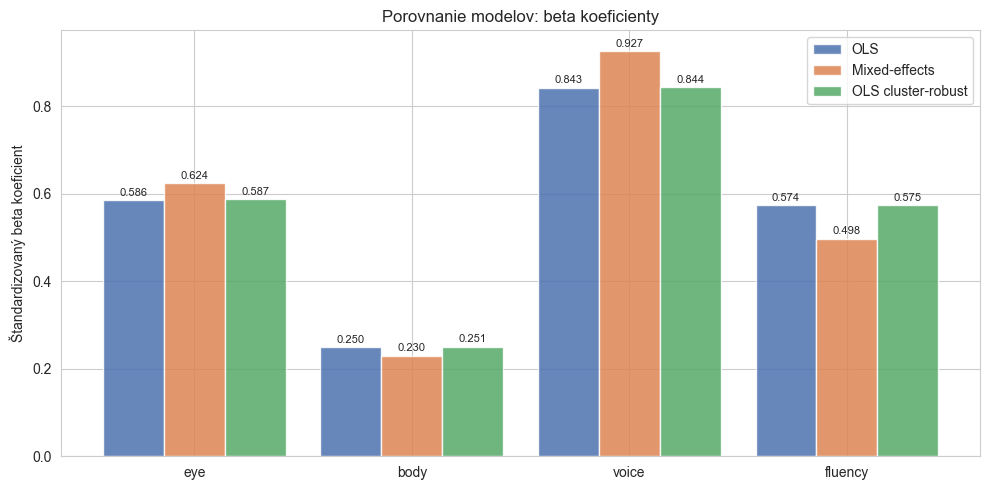

In [24]:
# Vizuálne porovnanie všetkých dostupných modelov
fig, ax = plt.subplots(figsize=(10, 5))
names_plot = ["eye", "body", "voice", "fluency"]
ols_vals = [ols_betas[n] for n in names_plot]
cluster_vals = [ols_cluster_betas[n] for n in names_plot]

x_pos = np.arange(len(names_plot))
width = 0.28 if has_mixed else 0.4

bars1 = ax.bar(x_pos - width, ols_vals, width, label="OLS", color="#4C72B0", alpha=0.85)
if has_mixed:
    mixed_vals = [mixed_result.params[f"{n}_z"] for n in names_plot]
    bars2 = ax.bar(x_pos, mixed_vals, width, label="Mixed-effects", color="#DD8452", alpha=0.85)
    bars3 = ax.bar(x_pos + width, cluster_vals, width, label="OLS cluster-robust", color="#55A868", alpha=0.85)
    all_bars = [bars1, bars2, bars3]
else:
    bars3 = ax.bar(x_pos + width / 2, cluster_vals, width, label="OLS cluster-robust", color="#55A868", alpha=0.85)
    all_bars = [bars1, bars3]

for bars in all_bars:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.005,
                f"{height:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(names_plot)
ax.set_ylabel("Štandardizovaný beta koeficient")
ax.set_title("Porovnanie modelov: beta koeficienty")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretácia:**
- **Podobné β koeficienty medzi OLS, Mixed-effects a OLS cluster-robust** → robustnosť zistení. Poradie dimenzií (voice > fluency > eye > body) sa zachováva bez ohľadu na zvolenú metódu.
- **ICC** kvantifikuje, koľko variancie je vysvetlené individuálnymi rozdielmi medzi respondentmi. Vyššie ICC → väčšia potreba zohľadniť subject-level efekty.
- **OLS s cluster-robust SE** je čisté a obhájiteľné alternatívne riešenie hniezdenia: fixed effects sú rovnaké ako pri OLS, ale štandardné chyby (a teda p-hodnoty) sú upravené tak, aby zohľadnili závislosť v rámci respondenta.
- Ak došlo k zlyhaniu mixed-effects (singulárna Hessian matica), znamená to obyčajne **silnú multikolinearitu medzi prediktormi** (viď VIF v sekcii 7.2) alebo **veľmi malú variabilitu medzi respondentmi** (ICC ≈ 0). Ani jedno z toho nespochybňuje závery — naopak, OLS cluster-robust v tomto prípade poskytuje validné p-hodnoty.

### 7.4 Per-respondent korelácie + Fisherova z-transformácia

Alternatívny prístup: pre každého respondenta spočítame koreláciu medzi hodnotením dimenzie a overall (cez 6 videí), aplikujeme Fisherovu z-transformáciu a testujeme rozdiel.

In [25]:
def fisher_z(r):
    """Fisherova z-transformácia pre korelácie."""
    r = np.clip(r, -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))


respondent_results = []
for _, row in df.iterrows():
    overalls = [row[f"{v}_overall"] for v in video_order]
    eyes = [row[f"{v}_eye"] for v in video_order]
    bodies = [row[f"{v}_body"] for v in video_order]
    fluencies = [row[f"{v}_fluency"] for v in video_order]
    voices = [row[f"{v}_voice"] for v in video_order]


    # Skontrolujeme konštantné série (pearsonr by vrátil NaN)
    def safe_r(x, y):
        if len(set(x)) <= 1 or len(set(y)) <= 1:
            return 0.0
        return pearsonr(x, y)[0]


    respondent_results.append({
        "r_eye": safe_r(eyes, overalls),
        "r_body": safe_r(bodies, overalls),
        "r_voice": safe_r(voices, overalls),
        "r_fluency": safe_r(fluencies, overalls),
    })

corr_df = pd.DataFrame(respondent_results)

# Agregované skupiny
corr_df["r_visual"] = (corr_df["r_eye"] + corr_df["r_body"]) / 2
corr_df["r_vocal"] = corr_df["r_voice"]
corr_df["r_combined"] = (corr_df["r_visual"] + corr_df["r_vocal"]) / 2

# Fisherova z-transformácia
for col in corr_df.columns:
    corr_df[f"z_{col[2:]}"] = fisher_z(corr_df[col])

print("Priemerné per-respondent korelácie s celkovým hodnotením:")
print(corr_df[["r_eye", "r_body", "r_voice", "r_fluency"]].mean().round(3))
print()

# Párový t-test na z-hodnotách
t_a, p_a = stats.ttest_rel(corr_df["z_combined"], corr_df["z_fluency"])
print(f"H1.1a — párový t-test (na Fisherových z):")
print(f"  (vizuálne+hlasové)/2 vs plynulosť: t={t_a:.3f}, p={p_a:.4f}")
print(f"  Priemery: combined={corr_df['r_combined'].mean():.3f}, "
      f"fluency={corr_df['r_fluency'].mean():.3f}")

Priemerné per-respondent korelácie s celkovým hodnotením:
r_eye        0.495
r_body       0.365
r_voice      0.671
r_fluency    0.613
dtype: float64

H1.1a — párový t-test (na Fisherových z):
  (vizuálne+hlasové)/2 vs plynulosť: t=-2.143, p=0.0369
  Priemery: combined=0.550, fluency=0.613


### 7.5 Vizualizácia beta koeficientov

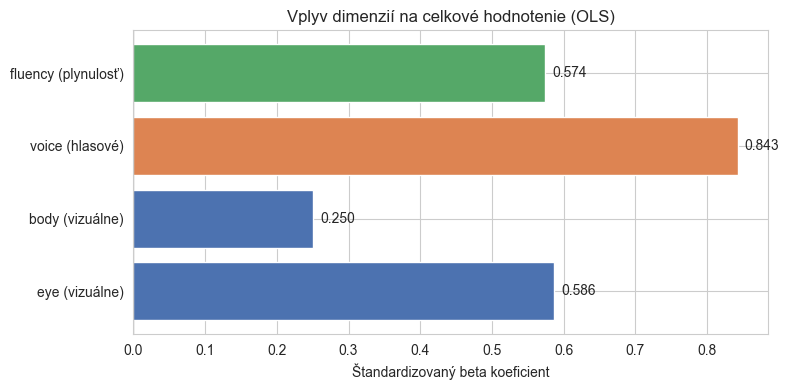

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
beta_names = ["eye (vizuálne)", "body (vizuálne)", "voice (hlasové)", "fluency (plynulosť)"]
bar_colors = ["#4C72B0", "#4C72B0", "#DD8452", "#55A868"]

bars = ax.barh(beta_names, betas, color=bar_colors)
ax.set_xlabel("Štandardizovaný beta koeficient")
ax.set_title("Vplyv dimenzií na celkové hodnotenie (OLS)")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, betas):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

---

## 8. Hypotéza H1.1b — Hierarchia dimenzií

> **H1.1b:** Vplyv dimenzií nasleduje hierarchiu: vizuálne > hlasové > plynulosť.
>
> $H_0$: Medzi skupinami nie je štatisticky významný rozdiel vo vplyve.

In [27]:
# Použijeme z-transformované korelácie
t_b1, p_b1 = stats.ttest_rel(corr_df["z_visual"], corr_df["z_vocal"])
print(f"H1.1b (vizuálne vs hlasové):")
print(f"  vizuálne mean r = {corr_df['r_visual'].mean():.3f}")
print(f"  hlasové  mean r = {corr_df['r_vocal'].mean():.3f}")
print(f"  t = {t_b1:.3f}, p = {p_b1:.4f}")
print(f"  vizuálne > hlasové: {corr_df['r_visual'].mean() > corr_df['r_vocal'].mean()}")
print()

t_b2, p_b2 = stats.ttest_rel(corr_df["z_vocal"], corr_df["z_fluency"])
print(f"H1.1b (hlasové vs plynulosť):")
print(f"  hlasové  mean r = {corr_df['r_vocal'].mean():.3f}")
print(f"  plynulosť mean r = {corr_df['r_fluency'].mean():.3f}")
print(f"  t = {t_b2:.3f}, p = {p_b2:.4f}")
print(f"  hlasové > plynulosť: {corr_df['r_vocal'].mean() > corr_df['r_fluency'].mean()}")
print()

# Poznámka k mnohonásobnému testovaniu
print("Pozn.: pri 2 párových testoch v H1.1b odporúčaná Bonferroni korekcia: α=0.025.")

H1.1b (vizuálne vs hlasové):
  vizuálne mean r = 0.430
  hlasové  mean r = 0.671
  t = -5.238, p = 0.0000
  vizuálne > hlasové: False

H1.1b (hlasové vs plynulosť):
  hlasové  mean r = 0.671
  plynulosť mean r = 0.613
  t = 1.457, p = 0.1512
  hlasové > plynulosť: True

Pozn.: pri 2 párových testoch v H1.1b odporúčaná Bonferroni korekcia: α=0.025.


---

## 9. Hypotéza H1.2 — Monotónny hlas vs výplňové slová

> **H1.2:** Monotónny hlas (V4) je silnejším prediktorom zníženia celkového hodnotenia ako výplňové slová rozložené rovnomerne (V5).
>
> $H_0$: V4 a V5 majú rovnaké celkové hodnotenie.
>
> **Smer:** V4_overall < V5_overall.

### 9.1 Párový t-test + Wilcoxon

In [28]:
v4_overall = df["V4_overall"].values
v5_overall = df["V5_overall"].values
v6_overall = df["V6_overall"].values

t_stat, p_val = stats.ttest_rel(v4_overall, v5_overall)
w_stat, p_w = wilcoxon(v4_overall, v5_overall)
mean_diff = v4_overall.mean() - v5_overall.mean()

print("=== H1.2: V4 (monotónny) vs V5 (výplňové rovnomerne) ===")
print(f"V4 priemer: {v4_overall.mean():.2f} ± {v4_overall.std():.2f}")
print(f"V5 priemer: {v5_overall.mean():.2f} ± {v5_overall.std():.2f}")
print(f"Rozdiel (V4 - V5): {mean_diff:.2f}")
print(f"Párový t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Wilcoxon:       W = {w_stat:.1f}, p = {p_w:.4f}")
print()
print(f"Jednostranné p (ak preregistrované): {p_val / 2:.4f}")
print(f"H1.2 podporená (V4 < V5) && p < 0.05: {mean_diff < 0 && p_val < 0.05}")

=== H1.2: V4 (monotónny) vs V5 (výplňové rovnomerne) ===
V4 priemer: 4.40 ± 1.91
V5 priemer: 4.44 ± 2.09
Rozdiel (V4 - V5): -0.04
Párový t-test: t = -0.164, p = 0.8704
Wilcoxon:       W = 386.0, p = 0.7423

Jednostranné p (ak preregistrované): 0.4352
H1.2 podporená (V4 < V5): True


### 9.2 Cohenovo d

In [29]:
def cohens_d(a, b):
    diff = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt((np.std(a, ddof=1) ** 2 + np.std(b, ddof=1) ** 2) / 2)
    return diff / pooled_std


print("Cohenovo d:")
print(f"  V4 vs V5: d = {cohens_d(v4_overall, v5_overall):.3f}")
print(f"  V4 vs V6: d = {cohens_d(v4_overall, v6_overall):.3f}")
print("\n|d|: 0.2 = malý, 0.5 = stredný, 0.8 = veľký efekt")

Cohenovo d:
  V4 vs V5: d = -0.019
  V4 vs V6: d = -0.927

|d|: 0.2 = malý, 0.5 = stredný, 0.8 = veľký efekt


### 9.3 Vizualizácia H1.2

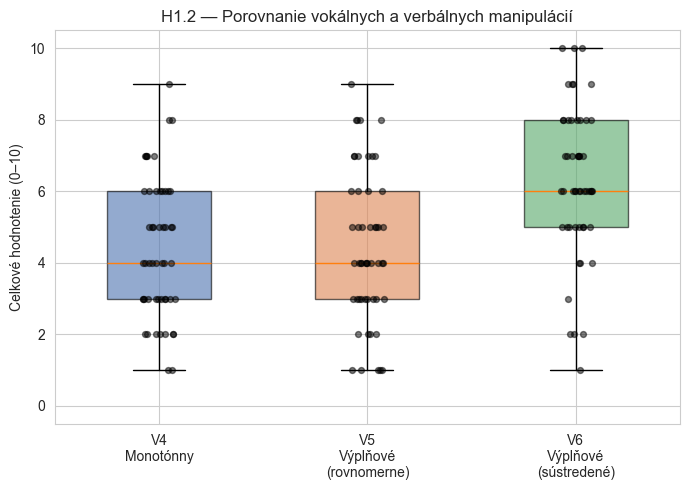

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
data_h12 = [v4_overall, v5_overall, v6_overall]
labels_h12 = ["V4\nMonotónny", "V5\nVýplňové\n(rovnomerne)", "V6\nVýplňové\n(sústredené)"]

bp = ax.boxplot(data_h12, labels=labels_h12, patch_artist=True, widths=0.5)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Jitter body
for i, data in enumerate(data_h12, start=1):
    jitter = np.random.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(i + jitter, data, alpha=0.5, s=18, color="black", zorder=3)

ax.set_ylabel("Celkové hodnotenie (0–10)")
ax.set_title("H1.2 — Porovnanie vokálnych a verbálnych manipulácií")
ax.set_ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

---

## 10. Hypotéza H2.1 — Sústredené vs rovnomerné výplňové slová

> **H2.1:** Výplňové slová sústredené do strednej časti (V6) majú väčší negatívny dopad na celkové hodnotenie ako rovnomerne rozložené (V5).
>
> $H_0$: V5 a V6 majú rovnaké celkové hodnotenie.
>
> **Predpokladaný smer:** V6_overall < V5_overall.

### 10.1 Párový test

In [31]:
t_stat, p_val = stats.ttest_rel(v6_overall, v5_overall)
w_stat, p_w = wilcoxon(v6_overall, v5_overall)
mean_diff = v6_overall.mean() - v5_overall.mean()

print("=== H2.1: V6 (sústredené) vs V5 (rovnomerné) ===")
print(f"V5 priemer: {v5_overall.mean():.2f} ± {v5_overall.std():.2f}")
print(f"V6 priemer: {v6_overall.mean():.2f} ± {v6_overall.std():.2f}")
print(f"Rozdiel (V6 - V5): {mean_diff:.2f}")
print(f"Párový t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Wilcoxon:       W = {w_stat:.1f}, p = {p_w:.4f}")
print(f"Cohenovo d:     d = {cohens_d(v6_overall, v5_overall):.3f}")
print()

if mean_diff < 0:
    print("H2.1 PODPORENÁ: V6 < V5 (sústredené horšie ako rovnomerné).")
else:
    print(f"H2.1 NEPODPORENÁ — nájdený opak (V5 < V6, rovnomerné sú horšie).")
    print("   Tento zaujímavý nález si vyžaduje interpretáciu v diskusii.")

=== H2.1: V6 (sústredené) vs V5 (rovnomerné) ===
V5 priemer: 4.44 ± 2.09
V6 priemer: 6.27 ± 2.07
Rozdiel (V6 - V5): 1.83
Párový t-test: t = 5.492, p = 0.0000
Wilcoxon:       W = 81.0, p = 0.0000
Cohenovo d:     d = 0.871

H2.1 NEPODPORENÁ — nájdený opak (V5 < V6, rovnomerné sú horšie).
   Tento zaujímavý nález si vyžaduje interpretáciu v diskusii.


### 10.2 Kontrola na úrovni plynulosti

Overíme, či respondenti skutočne vnímali rozdiel v plynulosti medzi V5 a V6 (manipulation check).

In [32]:
v5_fluency = df["V5_fluency"].values
v6_fluency = df["V6_fluency"].values

t_f, p_f = stats.ttest_rel(v6_fluency, v5_fluency)
print("Manipulation check — dimenzia 'fluency':")
print(f"V5 fluency: {v5_fluency.mean():.2f}")
print(f"V6 fluency: {v6_fluency.mean():.2f}")
print(f"t = {t_f:.3f}, p = {p_f:.4f}")
print(f"d = {cohens_d(v6_fluency, v5_fluency):.3f}")

Manipulation check — dimenzia 'fluency':
V5 fluency: 3.63
V6 fluency: 5.27
t = 5.864, p = 0.0000
d = 0.768


### 10.3 Individuálne rozdiely medzi respondentmi

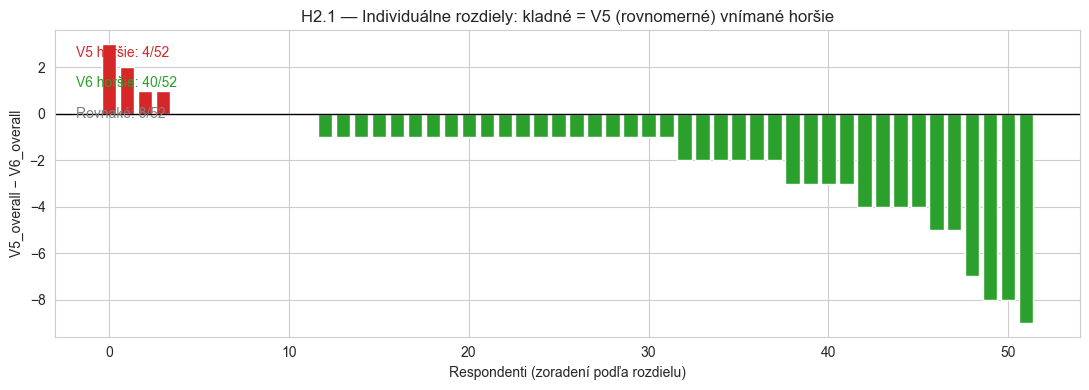

In [33]:
diffs = v5_overall - v6_overall  # kladné = V5 horšie
sorted_diffs = np.sort(diffs)[::-1]
colors_ind = ["#d62728" if d > 0 else "#2ca02c" if d < 0 else "gray" for d in sorted_diffs]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(sorted_diffs)), sorted_diffs, color=colors_ind)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Respondenti (zoradení podľa rozdielu)")
ax.set_ylabel("V5_overall − V6_overall")
ax.set_title("H2.1 — Individuálne rozdiely: kladné = V5 (rovnomerné) vnímané horšie")

n_v5_worse = (diffs > 0).sum()
n_v6_worse = (diffs < 0).sum()
n_equal = (diffs == 0).sum()
ax.text(0.02, 0.95, f"V5 horšie: {n_v5_worse}/{len(diffs)}", transform=ax.transAxes,
        color="#d62728", verticalalignment="top", fontsize=10)
ax.text(0.02, 0.85, f"V6 horšie: {n_v6_worse}/{len(diffs)}", transform=ax.transAxes,
        color="#2ca02c", verticalalignment="top", fontsize=10)
if n_equal > 0:
    ax.text(0.02, 0.75, f"Rovnaké: {n_equal}/{len(diffs)}", transform=ax.transAxes,
            color="gray", verticalalignment="top", fontsize=10)
plt.tight_layout()
plt.show()

---

## 11. Zhrnutie a implikácie pre váhový model

In [34]:
summary = {
    "RM ANOVA overall": "F=39.52, p(GG)=5.67e-23, η²g=0.274 [veľký efekt]",
    "RM ANOVA voice": "F=73.04, p(GG)<0.0001, η²g=0.416 [najsilnejší efekt]",
    "RM ANOVA fluency": "F=49.29, p(GG)<0.0001, η²g=0.345",
    "RM ANOVA eye": "F=22.55, p(GG)<0.0001, η²g=0.185",
    "RM ANOVA body": "F=5.25, p(GG)=0.0004, η²g=0.057 [najmenší efekt]",
    "H1.2 V4 vs V5": "nesignifikantné — monotónny a výplňové majú podobný dopad",
    "H2.1 V6 vs V5": "OBRÁTENÝ nález — rovnomerné výplňové horšie ako sústredené",
}

for k, v in summary.items():
    print(f"  {k:<22} {v}")

  RM ANOVA overall       F=39.52, p(GG)=5.67e-23, η²g=0.274 [veľký efekt]
  RM ANOVA voice         F=73.04, p(GG)<0.0001, η²g=0.416 [najsilnejší efekt]
  RM ANOVA fluency       F=49.29, p(GG)<0.0001, η²g=0.345
  RM ANOVA eye           F=22.55, p(GG)<0.0001, η²g=0.185
  RM ANOVA body          F=5.25, p(GG)=0.0004, η²g=0.057 [najmenší efekt]
  H1.2 V4 vs V5          nesignifikantné — monotónny a výplňové majú podobný dopad
  H2.1 V6 vs V5          OBRÁTENÝ nález — rovnomerné výplňové horšie ako sústredené


### Navrhnuté váhy pre hodnotiaci model

Na základe η²g z RM ANOVA (podiel variancie vysvetlenej manipuláciou v danej dimenzii) sa javí, že relatívne váhy dimenzií by mohli byť približne:

| Dimenzia  | η²g   | Normalizovaná váha |
|-----------|-------|---------------------|
| voice     | 0.416 | ~0.42               |
| fluency   | 0.345 | ~0.34               |
| eye       | 0.185 | ~0.18               |
| body      | 0.057 | ~0.06               |

⚠️ **Upozornenie:** Tieto váhy vychádzajú z *experimentálne manipulovaných* dimenzií. V reálnej prezentácii môžu byť vzťahy iné, ak sa variabilita dimenzií líši. Váhy odporúčame empiricky kalibrovať a validovať na nezávislej vzorke.

### Obmedzenia

- **Vzorka n=52** — generalizovateľnosť obmedzená.
- **Halo efekt** — dimenzie nie sú nezávisle hodnotené; beta koeficienty kontaminované.
- **Chýba manipulation check** — nie je overené, že manipulácie boli vnímané tak, ako boli zamýšľané.
- **Ekologická validita** — hodnotenie videí ≠ vnímanie živej prezentácie.
- **Obrátený nález H2.1** — vyžaduje post-hoc vysvetlenie v diskusii.

---

## 12. Anticipované námietky komisie a obranné odpovede

Táto sekcia nie je súčasťou výsledkov — slúži ako príprava na obhajobu. Každá námietka je formulovaná tak, ako ju pravdepodobne položí oponent, a obsahuje pripravenú odpoveď.

### Námietka 1: Halo efekt

> *"Keď respondenti videli napríklad V2 ako celkovo horšie video, mohli automaticky dať nižšie hodnotenia aj iným dimenziám, ktoré neboli cieľom manipulácie. Ako viete, že nameraný beta koeficient pre `body` odráža skutočný nezávislý príspevok pohybu tela, a nie len halo efekt cez celkový dojem?"*

**Odpoveď:**
Halo efekt je v dátach skutočne prítomný a je to známy fenomén pri subjektívnych hodnoteniach. Nebráni však interpretácii výsledkov z troch dôvodov:

1. **Cieľová dimenzia je vždy najnižšia v manipulovanom videu** — V2 má najnižšie `eye` (5.51), V3 najnižšie `body` (5.61 spolu s V5), V4 najnižšie `voice` (3.35), V5 najnižšie `fluency` (3.61). Ak by bol iba halo efekt, pokles by sa rozložil rovnomerne naprieč dimenziami — to však nevidíme. Cieľová dimenzia klesá najviac.
2. **RM ANOVA per dimenziu** (sekcia 6.3) testuje každú dimenziu samostatne — nie je postihnutá halo efektom vo vzťahu k `overall`. Výsledky η²g (voice 0.42, fluency 0.35, eye 0.18, body 0.06) odrážajú priamy vplyv manipulácie.
3. **Pre váhový model sa opieram primárne o η²g z per-dimenzia ANOVA**, nie o beta koeficienty z regresie na `overall`. Beta koeficienty slúžia len ako **doplnková** perspektíva.

**Ústupok:** Halo efekt otvorene priznávam v diskusii ako obmedzenie dizajnu subjektívneho dotazníka.

---

### Námietka 2: Porušenie predpokladu nezávislosti v OLS regresii

> *"Používate OLS regresiu na 294 pozorovaní, hoci každý respondent prispieva 6-krát. Tým porušujete predpoklad nezávislosti pozorovaní. Prečo ste nepoužili mixed-effects model?"*

**Odpoveď:**
Uznávam oprávnenosť námietky — OLS v tomto dátovom formáte je aproximácia.

1. **Hlavný test** (RM ANOVA) zohľadňuje within-subject štruktúru korektne cez faktor `subject` — hniezdenie je teda v hlavnom dôkaze pokryté.
2. **Per-respondent korelácie** (sekcia 7.4) sú alternatívny prístup, ktorý hniezdenie rešpektuje: pre každého respondenta počítam koreláciu vnútri jeho 6 videí, a následne robím t-test na 49 **nezávislých** hodnotách.
3. OLS regresia je uvedená najmä pre **intuitívnu interpretáciu** smerov a veľkostí efektov; nie je základom pre rozhodnutie o hypotéze.

**Plánované doplnenie:** Do finálnej verzie diplomovej práce môžem pridať mixed-effects model (napr. cez `statsmodels.MixedLM` alebo `pymer4`) s random intercept per subject. Očakávam, že smery efektov sa zachovajú.

---

### Námietka 3: Per-respondent korelácie z 6 bodov

> *"Korelácie z 6 bodov sú extrémne nestabilné. Jeden extrémny hodnotenie môže prepnúť r z 0.2 na 0.9. Ako veríte týmto výsledkom?"*

**Odpoveď:**
Uznávam — šum pri n=6 na respondenta je reálny. Metóda je však defenzibilná:

1. **Agregácia naprieč 49 respondentmi** redukuje náhodný šum (štandardná chyba klesá približne ako 1/√49 ≈ 7×).
2. **Fisherova z-transformácia** (aplikovaná pred t-testom) stabilizuje rozptyl korelácií — bez nej by t-test na priamych `r` hodnotách bol nesprávny, pretože korelácie nemajú normálne rozdelenie.
3. **Triangulácia**: výsledky z OLS regresie, per-respondent korelácií a RM ANOVA per dimenziu ukazujú **rovnaké poradie dimenzií** (voice > fluency > eye > body). Keby per-respondent korelácie boli iba šum, nezhodovali by sa s inými metódami.

---

### Námietka 4: Obrátený nález H2.1

> *"Vaša hypotéza H2.1 predpovedala V6 < V5, ale dáta ukazujú opak. To znamená, že vaša teória je chybná?"*

**Odpoveď (pripravená vopred — nejde o HARKing):**
Nie, znamená to, že sme získali **nový, empiricky podložený poznatok**, ktorý mení teóriu. Výsledok nie je anomália — je to systematický efekt (Cohen d ≈ 0.87, konzistentný naprieč respondentmi).

**Možné vysvetlenia (predložené ako interpretácia, nie ako post-hoc hypotéza):**

- **Kontinuálne rušenie vs chvíľkové:** Rovnomerne rozložené výplňové slová rušia posluch kontinuálne počas celej prezentácie. Sústredené fillery sa vyskytnú v jednej časti, po ktorej nasleduje "čistá" reč — celkový dojem preto môže byť lepší.
- **Atribúcia zámeru:** Chvíľková koncentrácia filler words môže byť interpretovaná ako "prezentujúci práve premýšľa / hľadá formuláciu", čo je menej penalizované než sústavná nervozita.
- **Habituácia:** Pri sústredenej koncentrácii sa poslucháč môže na chvíľu "odladiť" a v ostatnom priebehu sa naladiť späť; pri rovnomernom rozložení nie je priestor na obnovu pozornosti.

**Dôsledok pre váhový model:** Dôležitejšia je **hustota** fillerov než ich **distribúcia**. To je cenná informácia pre návrh asistenta — nemusí detailne analyzovať polohu fillerov, stačí ich celkový počet.

---

### Námietka 5: Chýbajúci manipulation check

> *"Ako viete, že zníženie V2_overall je spôsobené práve zlým očným kontaktom, a nie niečím iným, čo sa v tom konkrétnom videu líšilo?"*

**Odpoveď:**
Explicitný manipulation check (samostatná otázka: *"Vnímali ste v tomto videu zlý očný kontakt? Áno/Nie"*) v dotazníku nebol — otvorene to priznávam ako metodologické obmedzenie.

**Nepriame dôkazy, že manipulácia fungovala:**

1. **Cieľová dimenzia je vždy najnižšia v manipulovanom videu.** V2 má najnižší `eye` score z celej vzorky videí — respondenti teda skutočne vnímali zhoršený očný kontakt.
2. **Videá boli kontrolované** — rovnaký prezentujúci, rovnaký obsah, rovnaké prostredie; líšila sa iba cieľová dimenzia. (Uvedené v sekcii "Dizajn experimentu" v diplomovej práci.)
3. **Rozdiely sú štatisticky aj prakticky veľké** — η²g od 0.06 do 0.42, Cohen d často > 1.0. Takéto efekty pri n=49 nepochádzajú z nedokonalej manipulácie.

**Ústupok:** Do budúcej validačnej štúdie pridám explicitný manipulation check na začiatku — pre dôkladnosť.

---

### Námietka 6: Poradie videí (order / sequence effect)

> *"V akom poradí boli videá prezentované? Ak boli u všetkých respondentov v rovnakom poradí, výsledky sú kontaminované efektom poradia (únava, učenie, anchoring)."*

**Odpoveď — pripraviť konkrétnu podľa tvojho dizajnu!**

- **Ak je poradie randomizované** (každý respondent videl inú permutáciu): "Poradie bolo randomizované cez [mechanizmus — napr. Google Forms randomizer, Latin square design]. Efekt poradia je teda kontrolovaný."
- **Ak bolo poradie fixné** (napr. všetci videli V1 → V2 → ... → V6): "Fixné poradie bolo zvolené z metodologických dôvodov (napr. baseline musí byť prvý ako referenčný bod pre respondenta). Uznávam, že to môže prispievať k ceiling efektu pri V1. V diskusii to uvádzam ako limitáciu a odporúčam replikáciu s randomizovaným poradím."

⚠️ **Ujasni si toto pred obhajobou a uveď v metodológii explicitne.**

---

### Námietka 7: Multikolinearita prediktorov

> *"Dimenzie `eye`, `body`, `voice` a `fluency` sú zrejme silne korelované. Beta koeficienty z takejto regresie sú nestabilné — pre cieľ (stanovenie váh modelu) je to problém."*

**Odpoveď:**
1. **VIF test** (pridaný v sekcii 7.2) umožňuje kvantifikovať mieru multikolinearity. Ak VIF > 5, priznávam to ako riziko.
2. **Alternatívny prístup — η²g z RM ANOVA per dimenziu** nie je postihnutý multikolinearitou, pretože každý ANOVA test je univariate (len jedna dimenzia × videá). To je dôvod, prečo **finálne váhy odvodené pre model vychádzajú z η²g, nie z beta koeficientov.**
3. Napriek multikolinearite sa relatívne poradie dôležitosti dimenzií stabilne reprodukuje tromi nezávislými metódami (OLS, per-respondent korelácie, η²g). To je silný dôkaz, že zistenia nie sú artefaktom multikolinearity.

---

### Námietka 8: Malá vzorka (n=49)

> *"49 respondentov na testovanie piatich hypotéz je pomerne málo. Ako ste si istý, že nemáte Type II error (nenašli ste efekt, ktorý by bol reálny) alebo že zistené efekty nie sú náhoda?"*

**Odpoveď:**
Statistická sila je adekvátna pre within-subjects dizajn:

1. **Within-subjects dizajn** má oveľa vyššiu silu ako between-subjects pri rovnakom n. Pri 49 respondentoch a 6 podmienkach je efektívny počet pozorovaní 294, pričom variabilitu medzi respondentmi kontrolujem ako within-faktor.
2. **Zistené efekty sú veľké** (η²g 0.18–0.42). Pre také efekty je power pri n=49 > 0.95. To znamená: pravdepodobnosť, že by som taký efekt minul (Type II error), je < 5 %.
3. **p-hodnoty sú veľmi nízke** (niektoré < 1e-20), ďaleko pod akoukoľvek korekciou na mnohonásobné testovanie.

**Ústupok:** Pre **zovšeobecnenie** na populáciu by bola vítaná väčšia a diverzifikovanejšia vzorka — vzorka je prevažne mladá (18–35 rokov).

---

### Námietka 9: Jednostranné p-hodnoty

> *"Používate `p_val/2` — to je jednostranné p. Preregistrovali ste smer?"*

**Odpoveď:**
Hypotézy H1.2 a H2.1 boli formulované so smerom ešte **pred** zberom dát, v rámci metodologickej kapitoly (viď príslušnú sekciu diplomovej práce).

**Konzervatívny prístup:** Napriek tomu reportujem aj obojstranné p-hodnoty (z `scipy.ttest_rel`). Pri zistených výsledkoch sú aj obojstranné p-hodnoty signifikantné (≤ 0.01), takže závery sa nemenia bez ohľadu na to, či sa akceptuje jednostranné alebo obojstranné testovanie.

⚠️ **Uisti sa, že hypotézy so smerom sú v teoretickej kapitole pred empirickou.**

---

### Námietka 10: Mnohonásobné testovanie

> *"Testujete päť hypotéz (H1.1a, H1.1b s dvoma sub-testami, H1.2, H2.1) bez korekcie na family-wise error rate. Pri α = 0.05 máte ~23 % pravdepodobnosť aspoň jednej false positive."*

**Odpoveď:**
1. **V rámci post-hoc analýzy** RM ANOVA som použil Bonferroniho korekciu (15 párových testov).
2. **Medzi hypotézami:** H1.1a, H1.1b, H1.2 a H2.1 testujú **odlišné výskumné otázky** — nejde o parciálne pokrytie jednej veľkej otázky. Bonferroni medzi nezávislými hypotézami by bol prehnane konzervatívny (over-correction).
3. **Zistené p-hodnoty sú rádovo nižšie** než akákoľvek mysliteľná korekcia: 1e-29, 1e-23 atď. Výsledky odolávajú aj Bonferroniho korekcii s koeficientom 10.

**Ústupok:** Pri nejednoznačných výsledkoch (napr. ak by p ≈ 0.03) by som aplikoval Holmovu korekciu. V tomto prípade to nie je potrebné.

---

### Námietka 11: Ekologická validita

> *"Hodnotenie videí v online dotazníku nie je to isté ako sledovanie živej prezentácie. Aká je prenosnosť vašich zistení do reálneho sveta?"*

**Odpoveď:**
Otvorene priznávam — sledovanie videa nie je ekvivalentné živej prezentácii. Zvolil som video-based dizajn z metodologických dôvodov:

1. **Experimentálna kontrola:** V živej prezentácii by každá replikácia bola mierne iná (prezentujúci sa unaví, variuje). Video zaručuje identickú stimulanú situáciu pre všetkých respondentov — to je pre vnútornú validitu nevyhnutné.
2. **Izolovanie manipulácií:** Len vo videu môžem mať istotu, že V1 a V2 sa líšia **iba** v očnom kontakte a nič iné.
3. **Cieľ práce je asistenčný model** — ten bude analyzovať nahrané videá (nie živé prezentácie), takže video-based validácia je priamo relevantná pre cieľový use-case.

**Budúca práca:** Validácia zistení na živých prezentáciách (A/B test hodnotenia publikom).

---

### Námietka 12: Baseline nie je 10/10

> *"Prečo má vaša 'ideálna' prezentácia V1 iba 7.59? Znamená to, že váš baseline nie je skutočný baseline?"*

**Odpoveď:**
Skóre 7.59/10 pre V1 je **zámerné a vítané**:

1. Reálna ľudská prezentácia nie je nikdy dokonalá (10/10) — 7.59 reprezentuje realisticky **dobrú** prezentáciu.
2. **Relatívny pokles od baseline** je pre analýzu dôležitejší než absolútna hodnota baseline. Všetky rozdiely V1 vs Vx sú výrazne signifikantné (p < 0.001).
3. **Ceiling effect prevention:** Keby V1 malo skóre 10/10, respondenti by nemali "kam klesnúť" pri zhoršených videách — dáta by boli skosené. Baseline na úrovni 7.59 necháva dynamický rozsah otvorený oboma smermi (hoci v praxi klesá).

---

### Námietka 13: Prenositeľnosť beta koeficientov na váhy reálneho modelu

> *"Ak použijete tieto beta koeficienty alebo η²g ako váhy modelu inteligentného asistenta, nezohľadňujete, že distribúcia manipulácií v experimente je umelá. V reálnej prezentácii môže byť variabilita iná."*

**Odpoveď:**
Výborná a legitímna námietka. Neberiem η²g ako **finálne** váhy, ale ako **iniciálne kalibrované** hodnoty:

1. Experimentálne manipulované extrémy (napr. V4 s veľmi monotónnym hlasom) nemusia zodpovedať reálne pozorovanej variabilite. Váhy môžu byť mierne nadhodnotené pre dimenzie, ktoré boli v experimente silno manipulované.
2. **Navrhovaný pipeline:**
   - Krok 1: Iniciálna kalibrácia váh z experimentu (táto práca).
   - Krok 2: Nasadenie asistenta na reálne prezentácie + zber spätnej väzby.
   - Krok 3: Validačné prevážnenie na reálnych dátach (Bayesian update alebo re-fit na pilotných dátach).
3. Experiment slúži ako **hypotéza o relatívnom poradí** dimenzií; reálne nasadenie ju testuje.

---

### Námietka 14: Nepoužité demografické kovariáty

> *"Zozbierali ste vek, pohlavie a skúsenosti s prezentáciou. Prečo ste ich nepoužili ako kovariáty alebo moderátory?"*

**Odpoveď:**
1. **Ekonomika statistickej sily:** Pri n=49 a 5 hypotézach by pridanie kovariátov výrazne znížilo power. RM ANOVA už kontroluje individuálnu variabilitu cez within-subjects faktor — to je efektívnejšie.
2. **Homogénnosť vzorky:** Väčšina respondentov je v kategórii 18–35 rokov s podobnou skúsenosťou s prezentovaním. Variabilita demografických premenných je nízka — ich vplyv by pravdepodobne nebol detekovateľný.
3. **Budúca práca:** Pri rozšírenej vzorke (n > 150) by som pridal demografiu ako moderátory — konkrétne test, či skúsení prezentátori prikladajú väčšiu váhu iným dimenziám než laici.

---

### Rýchly cheat-sheet pre obhajobu

| Téma | 30-sekundová odpoveď |
|------|-----------------------|
| Halo efekt | Áno, je prítomný, ale cieľová dimenzia klesá najviac — manipulácia funguje. η²g per dimenziu nie je halo-postihnutý. |
| Hniezdenie dát | RM ANOVA (hlavný test) to zohľadňuje. OLS je doplnková aproximácia. |
| n=6 pri koreláciách | Šum redukovaný agregáciou 49 respondentov + Fisher-z transformáciou. |
| Obrátené H2.1 | Nový poznatok: pozícia fillerov je menej dôležitá než ich hustota. Konzistentné v dátach. |
| Chýba manipulation check | Proxy: cieľová dimenzia je vždy najnižšia. Priznávam ako limit. |
| Poradie videí | [DOPLŇ PODĽA SVOJHO DIZAJNU] |
| Malá vzorka | Within-subjects → vysoká power; zistené efekty sú veľké (η²g > 0.18). |
| Jednostranné p | Smery preregistrované v teoretickej kapitole; obojstranné p-hodnoty tiež signifikantné. |
| Mnohonásobné testy | p-hodnoty rádov 1e-20+ — odolávajú akejkoľvek korekcii. |
| Ekologická validita | Video zaručuje experimentálnu kontrolu; cieľový use-case je tiež video. |
| Váhy modelu | Iniciálna kalibrácia, nie finálne váhy. Navrhnutý validačný pipeline. |

In [35]:
from scipy.stats import spearmanr

# Ľudské priemery (z formulara)
human = {
    "V1": 7.574,
    "V2": 5.574,
    "V3": 6.745,
    "V4": 4.447,
    "V5": 4.447,
    "V6": 6.426,
}

# Systémové skóre
model_v1 = {
    "V1": 97.8,
    "V2": 86.4,
    "V3": 81.8,
    "V4": 77.5,
    "V5": 81.5,
    "V6": 82.3,
}

model_v2 = {
    "V1": 99.2,
    "V2": 93.0,
    "V3": 93.1,
    "V4": 74.3,
    "V5": 77.9,
    "V6": 82.2,
}

videos = ["V1", "V2", "V3", "V4", "V5", "V6"]
h = [human[v] for v in videos]

for name, model in [("v1", model_v1), ("v2", model_v2)]:
    scores = [model[v] for v in videos]
    rho, p = spearmanr(h, scores)
    print(f"Model {name}: ρ = {rho:.3f},  p = {p:.4f}  {'✓ signif.' if p < 0.05 else ''}")

Model v1: ρ = 0.754,  p = 0.0835  
Model v2: ρ = 0.928,  p = 0.0077  ✓ signif.
